### 0. Importer matplotlib (+pandas)

**Déf :** `Matplotlib est une bibliothèque du langage de programmation Python qui sert à tracer et à visualiser des données sous forme de graphiques`

Notes : 

- pandas pour manipuler les données
- matplotlib.pyplot pour créer les graphiques

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

### 1.1 Chargement des données

Le fichier des mesures IoT est importé dans un DataFrame nommé `df`. Ce `DataFrame` servira pour toutes les analyses et visualisations de l'atelier.

In [ ]:
df = pd.read_csv("../data/mesures_capteurs.csv")

df.head()

### 1.2 Évolution de la température

Afficher l'évolution de la température en fonction du temps avec un titre, les labels, la légende et la grille.

Le graphique permet également d'identifier visuellement les valeurs qui semblent anormales. :contentReference[oaicite:0]{index=0}

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date_heure"],
    df["temperature"],
    label="Température"
)

plt.title("Évolution de la température")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



### Identifier visuellement les valeurs qui semblent anormales: Analyse

À l'observation du graphique, on constate que la majorité des températures se situent entre **20 °C** et **30 °C**, ce qui traduit une évolution globalement stable au cours du temps.

Cependant, quelques valeurs s'écartent nettement de cette tendance :

- un **pic positif** proche de **60 °C**, beaucoup plus élevé que les autres mesures ;
- un **pic négatif** proche de **-20 °C**, très inférieur aux températures habituelles.

Ces deux mesures peuvent être considérées comme des **valeurs anormales (valeurs aberrantes)**. Elles peuvent être dues à un dysfonctionnement d'un capteur, à une erreur de mesure ou à un événement exceptionnel.

Enfin, l'axe des dates est très chargé, ce qui rend la lecture des différentes mesures difficile. Une amélioration de l'affichage pourra être envisageable.

### 2.1 Consommation moyenne par bâtiment

La méthode `groupby()` permet de regrouper les données selon une ou plusieurs catégories.

Associée à la méthode `mean()`, elle permet de calculer la consommation énergétique moyenne de chaque bâtiment.

In [ ]:
consommation_batiment = (
    df.groupby("batiment")["consommation"]
      .mean()
)

consommation_batiment

### 2.2 Diagramme en barres

La fonction `plt.bar()` permet de comparer des valeurs entre plusieurs catégories.

Ici, elle est utilisée pour comparer la consommation énergétique moyenne des différents bâtiments.

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    consommation_batiment.index,
    consommation_batiment.values
)

plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Analyse comparative

Le diagramme en barres permet de comparer rapidement et assez intuitivemment la consommation moyenne de chaque bâtiment.

Le bâtiment présentant la barre la plus haute est celui dont la consommation moyenne est la plus élevée, c'est à dire `B004` tandis que la barre la plus basse correspond au bâtiment le moins consommateur = `B003`.

### 2.3 Diagramme en barres horizontal

La fonction `plt.barh()` crée un diagramme en barres horizontal.

Ce type de graphique est particulièrement adapté lorsque les noms des catégories sont longs ou nombreux.

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    consommation_batiment.index,
    consommation_batiment.values
)

plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Consommation moyenne")
plt.ylabel("Bâtiment")
plt.grid(axis="x")

plt.tight_layout()
plt.show()

### 2.4 Zoom sur le diagramme en barre horizontal

Le diagramme horizontal présente les mêmes informations que le diagramme vertical.

Il facilite la lecture lorsque les noms des catégories sont longs ou lorsqu'il existe un grand nombre de bâtiments. Les étiquettes restent ainsi plus lisibles et ne se chevauchent pas.

### 3.1 Histogramme des températures

La fonction `plt.hist()` permet de représenter la distribution d'une variable numérique.

Ici, elle est utilisée pour visualiser la répartition des températures en les divisant en **20 classes**.

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["temperature"],
    bins=20
)

plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

### 3.2 Analyse de la distribution

L'histogramme montre que la majorité des températures sont concentrées entre **20 °C** et **30 °C**. Cette plage correspond aux mesures les plus fréquentes.

On observe également deux valeurs isolées :

- une température proche de **-20 °C** ;
- une température proche de **60 °C**.

Ces valeurs sont très éloignées de la distribution principale et peuvent être considérées comme des **valeurs aberrantes**. Elles peuvent être dues à une erreur de mesure, à un dysfonctionnement du capteur ou à un événement exceptionnel.

La distribution est globalement concentrée autour de **25 °C**, ce qui indique que les températures mesurées sont relativement stables en dehors de ces quelques anomalies.

#### **3.2.a** Où se concentrent les températures ?

Les températures se concentrent principalement entre **20 °C** et **30 °C**. Cette plage regroupe la majorité des mesures enregistrées.

#### **3.2.b** La distribution semble-t-elle symétrique ?

La distribution est globalement centrée autour de **25 °C**, mais elle n'est pas parfaitement symétrique en raison de quelques valeurs extrêmes.

#### **3.2.c** Existe-t-il des valeurs très éloignées ?

Oui. Deux mesures sont très éloignées de l'ensemble des données :

- une température proche de **-20 °C** ;
- une température proche de **60 °C**.

#### **3.2.d** Des valeurs aberrantes sont-elles visibles ?

Oui. Les deux valeurs extrêmes observées peuvent être considérées comme des **valeurs aberrantes (outliers)**. Elles peuvent être dues à une erreur de mesure, à un dysfonctionnement du capteur ou à un événement exceptionnel.

### 3.3 Histogramme des consommations

La fonction `plt.hist()` peut également être utilisée pour représenter la distribution de la consommation énergétique.

Le nombre de classes est fixé à **20**.

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["consommation"],
    bins=20
)

plt.title("Distribution de la consommation")
plt.xlabel("Consommation")
plt.ylabel("Nombre de mesures")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

### 3.3 [a - c] Influence du nombre de classes

Le paramètre `bins` permet de définir le nombre de classes de l'histogramme.

Comparer le rendu avec **10** puis **30** classes permet de mieux comprendre son influence sur la visualisation.

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["consommation"],
    bins=10
)

plt.title("Distribution de la consommation (10 classes)")
plt.xlabel("Consommation")
plt.ylabel("Nombre de mesures")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["consommation"],
    bins=30
)

plt.title("Distribution de la consommation (30 classes)")
plt.xlabel("Consommation")
plt.ylabel("Nombre de mesures")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Quel impact le nombre de classes a-t-il sur l'interprétation

Le nombre de classes influence directement la lecture de l'histogramme :

- avec **10 classes**, la distribution est plus simple à lire mais moins détaillée ;
- avec **30 classes**, davantage de détails apparaissent, au risque de rendre le graphique plus difficile à interpréter.

Le choix du nombre de classes dépend donc du niveau de précision souhaité.

### 4.1 Nuage de points température et consommation

La fonction `plt.scatter()` permet de représenter la relation entre deux variables numériques.

Ici, elle est utilisée pour visualiser le lien entre la température et la consommation énergétique.

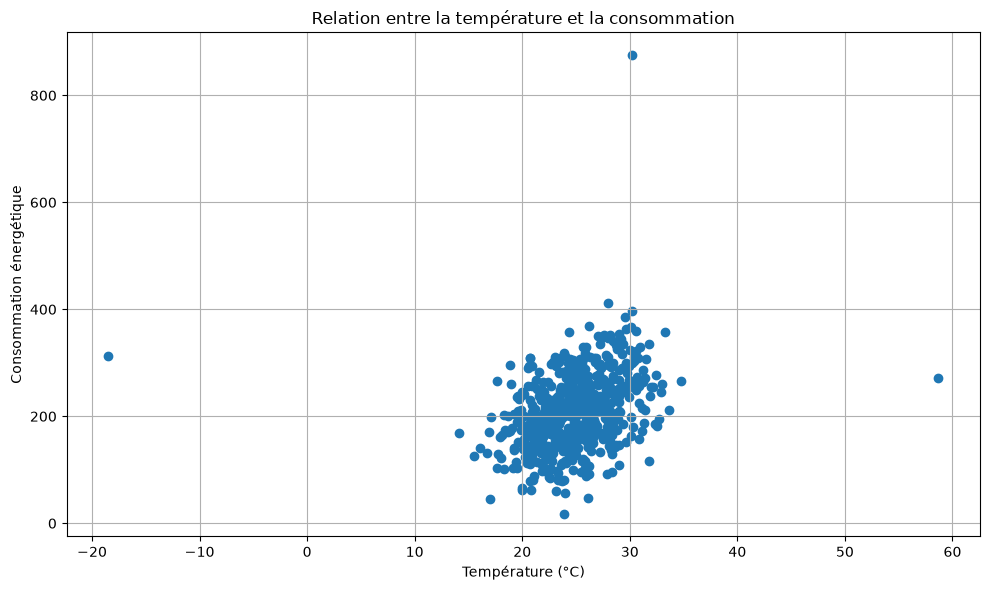

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["temperature"],
    df["consommation"]
)

plt.title("Relation entre la température et la consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation énergétique")

plt.grid(True)

plt.tight_layout()
plt.show()